In [1]:
import torch
import torch_geometric
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors
from rdkit.Chem import rdMolDescriptors
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch: {torch.__version__}")
print(f"PyTorch Geometric: {torch_geometric.__version__}")
from rdkit import __version__ as rdkit_version
print(f"RDKit: {rdkit_version}")
print("\nAll imports successful")

PyTorch: 2.10.0+cpu
PyTorch Geometric: 2.7.0
RDKit: 2025.09.6

All imports successful


In [7]:
import requests
import os

os.makedirs('../data', exist_ok=True)

files = {
    'https://raw.githubusercontent.com/hkmztrk/DeepDTA/master/data/davis/ligands_can.txt': '../data/davis_drugs.txt',
    'https://raw.githubusercontent.com/hkmztrk/DeepDTA/master/data/davis/proteins.txt': '../data/davis_proteins.txt',
    'https://raw.githubusercontent.com/hkmztrk/DeepDTA/master/data/davis/Y': '../data/davis_affinity.txt',
}

for url, path in files.items():
    print(f"Downloading {path}...")
    r = requests.get(url)
    if r.status_code == 200:
        with open(path, 'wb') as f:  # write as bytes
            f.write(r.content)
        print(f"  done")
    else:
        print(f"  failed ({r.status_code})")

print("\nAll files downloaded")

  done
  done
  done

All files downloaded


In [9]:
import numpy as np

# load drugs (SMILES strings)
with open('../data/davis_drugs.txt', 'r') as f:
    drugs = [line.strip() for line in f.readlines()]

# load proteins (amino acid sequences)
with open('../data/davis_proteins.txt', 'r') as f:
    proteins = [line.strip() for line in f.readlines()]

# load affinity matrix — binary numpy format
affinity = np.load('../data/davis_affinity.txt', allow_pickle=True)

print(f"Number of drugs:    {len(drugs)}")
print(f"Number of proteins: {len(proteins)}")
print(f"Affinity matrix:    {affinity.shape}")
print(f"\nSample drug SMILES:")
print(f"  {drugs[0]}")
print(f"\nSample protein sequence (first 50 chars):")
print(f"  {proteins[0][:50]}...")
print(f"\nAffinity values range:")
print(f"  Min: {affinity.min():.2f}")
print(f"  Max: {affinity.max():.2f}")
print(f"  Mean: {affinity.mean():.2f}")

C:\Users\hidey\AppData\Roaming\Python\Python314\site-packages\numpy\lib\_npyio_impl.py:494: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(fid, **pickle_kwargs)


UnpicklingError: Failed to interpret file '../data/davis_affinity.txt' as a pickle

In [10]:
import requests
import numpy as np
import io
import os

# download the correct numpy binary file
url = "https://raw.githubusercontent.com/hkmztrk/DeepDTA/master/data/davis/Y"
r = requests.get(url)

# save as binary
with open('../data/davis_affinity.npy', 'wb') as f:
    f.write(r.content)

# try loading as numpy binary
try:
    affinity = np.load('../data/davis_affinity.npy', allow_pickle=True)
    print(f"Loaded as numpy: {affinity.shape}")
except:
    # if that fails, try reading as text with latin encoding
    content = r.content.decode('latin-1')
    lines = [l.strip() for l in content.split('\n') if l.strip()]
    print(f"First line: {lines[0][:100]}")
    print(f"Total lines: {len(lines)}")

First line: cnumpy.core.multiarray
Total lines: 66


In [11]:
import pickle
import numpy as np

# load as pickle
with open('../data/davis_affinity.npy', 'rb') as f:
    affinity = pickle.load(f, encoding='latin1')

affinity = np.array(affinity)

print(f"Affinity matrix shape: {affinity.shape}")
print(f"Min: {affinity.min():.2f}")
print(f"Max: {affinity.max():.2f}")
print(f"Mean: {affinity.mean():.2f}")

Affinity matrix shape: (68, 442)
Min: 0.02
Max: 10000.00
Mean: 7415.88


C:\Users\hidey\AppData\Local\Temp\ipykernel_22660\3289104651.py:6: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  affinity = pickle.load(f, encoding='latin1')


In [14]:
# use raw directly — it's already the correct 68x442 matrix
affinity = raw
print(f"Affinity matrix shape: {affinity.shape}")

# binarize — threshold 30 nM
threshold = 30.0

drug_indices = []
protein_indices = []
labels = []
affinities_flat = []

for i in range(affinity.shape[0]):
    for j in range(affinity.shape[1]):
        drug_indices.append(i)
        protein_indices.append(j)
        aff = affinity[i][j]
        affinities_flat.append(aff)
        labels.append(1 if aff <= threshold else 0)

labels = np.array(labels)
affinities_flat = np.array(affinities_flat)

print(f"Total drug-target pairs: {len(labels)}")
print(f"Positive (binds):        {labels.sum()} ({labels.mean()*100:.1f}%)")
print(f"Negative (no binding):   {(1-labels).sum()} ({(1-labels).mean()*100:.1f}%)")
print(f"\nAffinity distribution:")
print(f"  <= 30 nM:    {(affinities_flat <= 30).sum()} pairs")
print(f"  <= 100 nM:   {(affinities_flat <= 100).sum()} pairs")
print(f"  <= 1000 nM:  {(affinities_flat <= 1000).sum()} pairs")
print(f"  > 1000 nM:   {(affinities_flat > 1000).sum()} pairs")

Affinity matrix shape: (68, 442)
Total drug-target pairs: 30056
Positive (binds):        1527 (5.1%)
Negative (no binding):   28529 (94.9%)

Affinity distribution:
  <= 30 nM:    1527 pairs
  <= 100 nM:   2502 pairs
  <= 1000 nM:  5561 pairs
  > 1000 nM:   24495 pairs


In [13]:
import pickle
import numpy as np

with open('../data/davis_affinity.npy', 'rb') as f:
    raw = pickle.load(f, encoding='latin1')

print(f"Type: {type(raw)}")
print(f"Value: {raw}")

# if it's a dict or nested structure
if isinstance(raw, dict):
    print(f"Keys: {list(raw.keys())}")
elif hasattr(raw, '__len__'):
    print(f"Length: {len(raw)}")
    print(f"First element type: {type(raw[0])}")
    print(f"First element: {raw[0]}")

Type: <class 'numpy.ndarray'>
Value: [[4.3e+01 1.0e+04 1.0e+04 ... 2.3e+02 1.0e+04 1.0e+04]
 [1.0e+04 1.0e+04 1.0e+04 ... 2.0e+03 1.0e+04 1.0e+04]
 [1.0e+04 7.5e+01 1.9e+00 ... 1.2e+02 2.3e+00 1.0e+04]
 ...
 [1.0e+04 1.3e+01 7.7e+02 ... 9.8e+02 5.1e+03 1.0e+04]
 [6.3e+01 6.3e+01 6.9e+03 ... 5.2e+00 1.0e+04 3.5e+03]
 [1.0e+04 1.0e+04 1.0e+04 ... 1.9e+03 4.4e+03 1.0e+04]]
Length: 68
First element type: <class 'numpy.ndarray'>
First element: [4.3e+01 1.0e+04 1.0e+04 1.0e+04 1.0e+04 1.0e+04 1.0e+04 1.0e+04 1.0e+04
 1.0e+04 1.0e+04 1.0e+04 1.0e+04 1.0e+04 1.0e+04 1.0e+04 1.0e+04 1.0e+04
 1.0e+04 1.0e+04 1.0e+04 1.0e+04 1.0e+04 1.0e+04 7.6e+01 2.9e+03 1.8e+02
 1.0e+04 1.0e+04 1.0e+04 1.0e+04 1.0e+04 1.0e+04 1.0e+04 1.0e+04 1.0e+04
 8.4e+03 1.0e+04 1.2e+02 1.0e+04 1.0e+04 1.0e+04 1.0e+04 1.0e+04 1.0e+04
 1.0e+04 1.0e+04 1.0e+04 1.0e+04 1.0e+04 1.0e+04 2.4e+03 1.0e+04 3.2e+02
 9.7e+02 2.7e+02 8.9e+02 7.1e+02 8.1e+02 7.4e+02 1.0e+04 1.0e+04 1.0e+04
 3.1e+03 1.3e+03 1.0e+04 2.7e+03 1.0e+04 1.0e+

C:\Users\hidey\AppData\Local\Temp\ipykernel_22660\1200132861.py:5: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  raw = pickle.load(f, encoding='latin1')


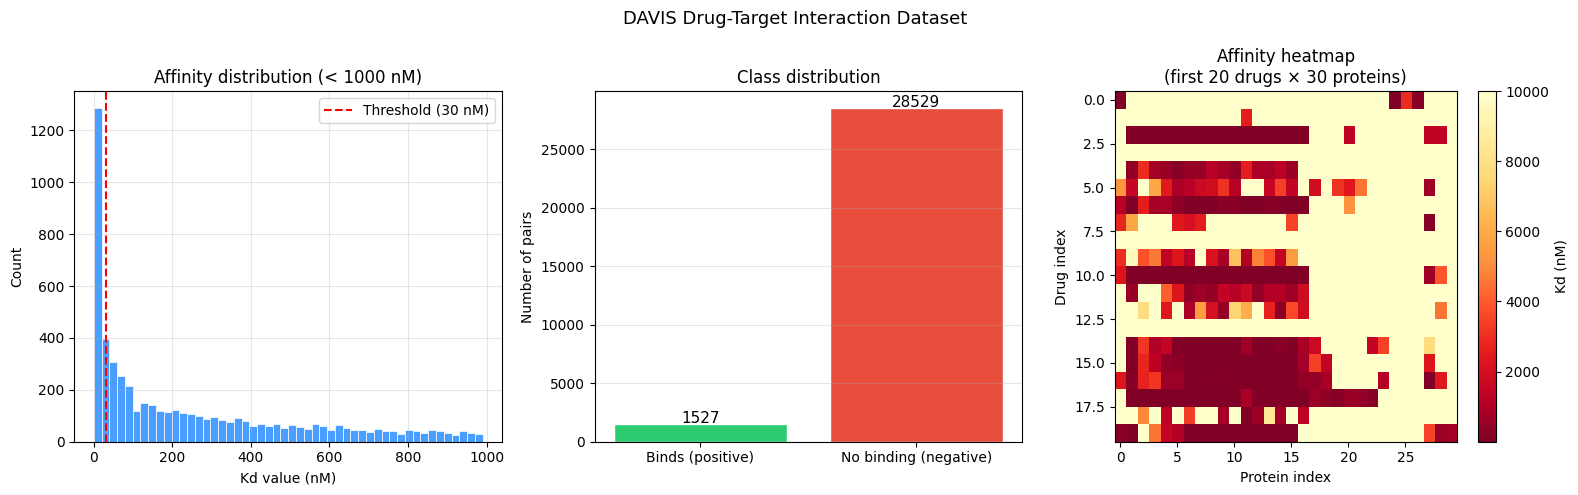

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# affinity distribution
axes[0].hist(affinities_flat[affinities_flat < 1000], 
             bins=50, color='#4a9eff', edgecolor='white', linewidth=0.5)
axes[0].axvline(x=30, color='red', linestyle='--', 
                label='Threshold (30 nM)')
axes[0].set_title('Affinity distribution (< 1000 nM)')
axes[0].set_xlabel('Kd value (nM)')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(alpha=0.3)

# class distribution
counts = [labels.sum(), (1-labels).sum()]
colors = ['#2ecc71', '#e74c3c']
axes[1].bar(['Binds (positive)', 'No binding (negative)'], 
            counts, color=colors, edgecolor='white')
for i, c in enumerate(counts):
    axes[1].text(i, c + 100, str(c), ha='center', fontsize=11)
axes[1].set_title('Class distribution')
axes[1].set_ylabel('Number of pairs')
axes[1].grid(axis='y', alpha=0.3)

# affinity heatmap (subset)
im = axes[2].imshow(affinity[:20, :30], cmap='YlOrRd_r', aspect='auto')
axes[2].set_title('Affinity heatmap\n(first 20 drugs × 30 proteins)')
axes[2].set_xlabel('Protein index')
axes[2].set_ylabel('Drug index')
plt.colorbar(im, ax=axes[2], label='Kd (nM)')

plt.suptitle('DAVIS Drug-Target Interaction Dataset', fontsize=13)
plt.tight_layout()
plt.show()